In [5]:
pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, classification_report,confusion_matrix, roc_auc_score, roc_curve)
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

print("Semua library berhasil diimport!")

Semua library berhasil diimport!


: 

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/PA 3 KEL 10-20260406T061058Z-3-001/PA 3 KEL 10/ML/diabetes_dataset.csv')
print("Dataset berhasil dimuat!")
print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset berhasil dimuat!
Jumlah baris: 100000
Jumlah kolom: 16


,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0
3,2015,Male,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0
4,2016,Female,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0


: 

eksplorasi data (EDA)

In [ ]:
df.info()
print("\n")
print(df.describe())
print("\nMissing values:")
print(df.isnull().sum())
print("\nDistribusi label:")

<class 'pandas.core.frame.DataFrame'>
Index: 90387 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   year                         90387 non-null  float64
 1   age                          90387 non-null  float64
 2   location                     90387 non-null  float64
 3   race:AfricanAmerican         90387 non-null  float64
 4   race:Asian                   90387 non-null  float64
 5   race:Caucasian               90387 non-null  float64
 6   race:Hispanic                90387 non-null  float64
 7   race:Other                   90387 non-null  float64
 8   hypertension                 90387 non-null  float64
 9   heart_disease                90387 non-null  float64
 10  bmi                          90387 non-null  float64
 11  hbA1c_level                  90387 non-null  float64
 12  blood_glucose_level          90387 non-null  float64
 13  diabetes             

: 

In [ ]:
print(df.isnull().sum())

year                    0
gender                  0
age                     0
location                0
race:AfricanAmerican    0
race:Asian              0
race:Caucasian          0
race:Hispanic           0
race:Other              0
hypertension            0
heart_disease           0
smoking_history         0
bmi                     0
hbA1c_level             0
blood_glucose_level     0
diabetes                0
dtype: int64


: 

<Axes: ylabel='bmi'>

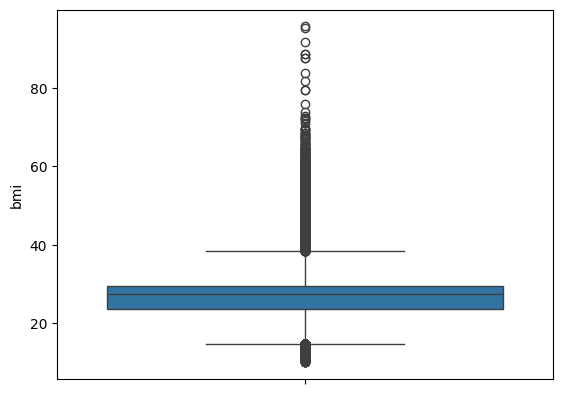

: 

In [ ]:
sns.boxplot(df['bmi'])

In [ ]:
print(df['diabetes'].value_counts())

diabetes
0    91500
1     8500
Name: count, dtype: int64


: 

In [ ]:
print(df['smoking_history'].unique())
print(df[df['age'] < 10])

['never' 'not current' 'current' 'No Info' 'ever' 'former']
       year  gender   age location  race:AfricanAmerican  race:Asian  \
12     2015  Female  3.00  Alabama                     1           0   
16     2015  Female  2.00  Alabama                     0           1   
38     2015    Male  3.00  Alabama                     0           0   
40     2016    Male  8.00  Alabama                     0           1   
46     2015    Male  5.00  Alabama                     0           0   
...     ...     ...   ...      ...                   ...         ...   
99943  2016    Male  3.00  Wyoming                     0           1   
99944  2016  Female  2.00  Wyoming                     0           0   
99947  2016  Female  6.00  Wyoming                     1           0   
99983  2016    Male  5.00  Wyoming                     0           0   
99991  2016    Male  1.48  Wyoming                     0           0   

       race:Caucasian  race:Hispanic  race:Other  hypertension  heart_disea

: 

# Preprocessing: Noise, Outlier, dan Data Imbalance

Handle Noise mengisi NaN dengan modus:

In [ ]:
df['smoking_history'] = df['smoking_history'].replace(
    'No Info', 
    df[df['smoking_history'] != 'No Info']['smoking_history'].mode()[0]
)


KeyError: 'smoking_history'

: 

In [ ]:
print(df['smoking_history'].head())

0    never
1    never
2    never
3    never
4    never
Name: smoking_history, dtype: object


: 

In [ ]:
print(df['smoking_history'].value_counts())

smoking_history
never          70911
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64


: 

Handle Outlier (menggunakan IQR pada kolom numerik)

In [ ]:
def remove_outlier_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return data[(data[column] >= lower) & (data[column] <= upper)]

for col in ['age', 'bmi', 'hbA1c_level', 'blood_glucose_level']:
    df = remove_outlier_iqr(df, col)

: 

In [ ]:
print("-" * 50 + f"\nTotal baris akhir setelah handling outlier: {len(df)}")

--------------------------------------------------
Total baris akhir setelah handling outlier: 84784


: 

Handle Data Imbalance

In [ ]:
X = df.drop('diabetes', axis=1)
y = df['diabetes']
# Label encoding untuk fitur kategorikal sebelum SMOTE
for col in X.select_dtypes(include=['object']).columns:
    X[col] = LabelEncoder().fit_transform(X[col])
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)
print('Sebelum SMOTE:', y.value_counts().to_dict())
print('Setelah SMOTE:', dict(zip(*np.unique(y_res, return_counts=True))))

Sebelum SMOTE: {0: 80751, 1: 4033}
Setelah SMOTE: {np.int64(0): np.int64(80751), np.int64(1): np.int64(80751)}


: 

# Feature Engineering, Encoding, Scaling, dan Dimensionality Reduction

Feature Engineering (contoh: membuat fitur baru dari clinical_notes jika ada)

In [ ]:
if 'clinical_notes' in df.columns:
    df['notes_length'] = df['clinical_notes'].astype(str).apply(len)

: 

Encoding (Label Encoding untuk kolom kategorikal, OneHot untuk yang sedikit unik)

In [ ]:

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
if 'clinical_notes' in categorical_cols:
    categorical_cols.remove('clinical_notes') 
for col in categorical_cols:
    if df[col].nunique() <= 5:
        df = pd.get_dummies(df, columns=[col], drop_first=True)
    else:
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))


: 

Scaling/Normalisasi (StandardScaler untuk numerik)

In [ ]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
if 'diabetes' in numeric_cols:
    numeric_cols.remove('diabetes')
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])



: 

Dimensionality Reduction (opsional, contoh dengan PCA)

In [ ]:
do_pca = True 
if do_pca:
    pca = PCA(n_components=0.95, random_state=42)  # Simpan 95% variansi
    features = df.drop(['diabetes'], axis=1)
    features_pca = pca.fit_transform(features)
    df_pca = pd.DataFrame(features_pca, columns=[f'PC{i+1}' for i in range(features_pca.shape[1])])
    df_pca['diabetes'] = df['diabetes'].values
    print('Shape setelah PCA:', df_pca.shape)
else:
    df_pca = df.copy()

df_pca.head()

Shape setelah PCA: (90387, 13)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,diabetes
0,-0.652048,-0.692111,-0.360743,1.982971,-0.682002,-2.034151,-0.995610,-0.028434,0.392901,-0.050585,-0.044409,-0.305931,0
1,-1.402784,-0.785256,2.130622,-0.593679,-0.159983,0.564573,-1.069039,0.178682,1.511050,-2.548362,0.242454,0.477484,0
2,-1.184937,-0.614219,-0.187574,2.011738,-0.637348,0.585043,0.103691,-0.932273,0.355826,-2.960173,0.015044,-0.445235,0
3,-0.220483,-0.367616,-1.169554,-1.307700,-1.207442,0.691890,-0.784165,-1.531466,0.068234,-2.927654,-0.276888,-0.136787,0
4,-0.226830,2.202218,0.344618,0.167925,-0.123888,0.033960,-0.368083,0.165532,2.427810,-1.557826,-0.110564,0.776306,0


: 

In [ ]:
# Implementasi Random Forest untuk klasifikasi diabetes
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split

# Gunakan df_pca jika sudah ada, jika tidak gunakan df
if 'df_pca' in globals():
    data = df_pca
else:
    data = df

X = data.drop('diabetes', axis=1)
y = data['diabetes']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_rf))
print('\nClassification Report:')
print(classification_report(y_test, y_pred_rf))
print('Akurasi:', accuracy_score(y_test, y_pred_rf))

Confusion Matrix:
[[17130    49]
 [  527   372]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     17179
           1       0.88      0.41      0.56       899

    accuracy                           0.97     18078
   macro avg       0.93      0.71      0.77     18078
weighted avg       0.97      0.97      0.96     18078

Akurasi: 0.968138068370395


: 

### 1. Feature Selection (Random Forest Feature Importance)

In [ ]:
# Feature Selection dengan Feature Importance dari Random Forest
importances = rf.feature_importances_
feature_names = X.columns
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)
print('Feature Importance:')
print(feat_imp)

# Pilih fitur teratas (misal: 10 fitur terpenting)
top_n = 10
selected_features = feat_imp.head(top_n).index.tolist()
X_selected = X[selected_features]

Feature Importance:
PC7     0.248335
PC1     0.143718
PC9     0.088679
PC11    0.081137
PC8     0.072023
PC2     0.060483
PC3     0.058134
PC10    0.053659
PC12    0.053350
PC4     0.048674
PC6     0.048218
PC5     0.043590
dtype: float64


: 

### 2A. Model Sebelum Tuning (Baseline Performance)

In [ ]:
# Evaluasi Random Forest baseline (sebelum tuning)
from sklearn.model_selection import cross_val_score

print("="*60)
print("BASELINE MODEL (Random Forest default)")
print("="*60)

# Subset X_selected untuk train dan test set
X_selected_train = X_train[selected_features]
X_selected_test = X_test[selected_features]

# Train baseline model dengan default parameters pada selected features
rf_baseline = RandomForestClassifier(random_state=42, n_jobs=1)
rf_baseline.fit(X_selected_train, y_train)
y_pred_baseline = rf_baseline.predict(X_selected_test)

# Baseline performance
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_cv = cross_val_score(rf_baseline, X_selected_train, y_train, cv=3, scoring='accuracy')

print(f"Test Accuracy (Baseline): {baseline_accuracy:.4f}")
print(f"CV Accuracy (Baseline): {baseline_cv.mean():.4f} (+/- {baseline_cv.std():.4f})")
print(f"\nClassification Report (Baseline):")
print(classification_report(y_test, y_pred_baseline))
print()

BASELINE MODEL (Random Forest default)
Test Accuracy (Baseline): 0.9684
CV Accuracy (Baseline): 0.9679 (+/- 0.0005)

Classification Report (Baseline):
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     17179
           1       0.88      0.42      0.57       899

    accuracy                           0.97     18078
   macro avg       0.93      0.71      0.78     18078
weighted avg       0.97      0.97      0.96     18078




: 

### 2B. Hyperparameter Tuning (Metode: GridSearchCV)

In [11]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Definisikan param_grid agar tidak error
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

# Inisialisasi model dengan penanganan data imbalanced
rf_grid = RandomForestClassifier(random_state=42, class_weight='balanced')

grid_search = GridSearchCV(
    estimator=rf_grid, 
    param_grid=param_grid, 
    cv=3, 
    scoring='f1', 
    n_jobs=-1, 
    verbose=1
)

print("Fitting GridSearchCV... (Mencari kombinasi terbaik untuk F1-Score)\n")
grid_search.fit(X_selected_train, y_train)

print("\n" + "="*60)
print("Best Parameters Found:")
print("="*60)
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Score (F1): {grid_search.best_score_:.4f}\n")


Fitting GridSearchCV... (Mencari kombinasi terbaik untuk F1-Score)



NameError: name 'X_selected_train' is not defined

### 2C. Model Setelah Tuning (Tuned Performance) & Comparison

In [ ]:
# Evaluasi model setelah tuning dan bandingkan dengan baseline
print("="*60)
print("TUNED MODEL PERFORMANCE")
print("="*60)

# Get best model dari GridSearchCV
best_rf = grid_search.best_estimator_

# Prediksi dengan tuned model pada test set
y_pred_tuned = best_rf.predict(X_selected_test)
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)

# Cross validation score untuk tuned model
tuned_cv = cross_val_score(best_rf, X_selected_train, y_train, cv=3, scoring='accuracy')

print(f"Test Accuracy (Tuned): {tuned_accuracy:.4f}")
print(f"CV Accuracy (Tuned): {tuned_cv.mean():.4f} (+/- {tuned_cv.std():.4f})")
print(f"\nConfusion Matrix (Tuned):")
print(confusion_matrix(y_test, y_pred_tuned))
print(f"\nClassification Report (Tuned):")
print(classification_report(y_test, y_pred_tuned))

print("\n" + "="*60)
print("PERBANDINGAN: BASELINE vs TUNED MODEL")
print("="*60)
improvement = ((tuned_accuracy - baseline_accuracy) / baseline_accuracy) * 100
print(f"Baseline Accuracy:  {baseline_accuracy:.4f}")
print(f"Tuned Accuracy:     {tuned_accuracy:.4f}")
print(f"Improvement:        {improvement:+.2f}%")
print(f"\nBaseline CV Score:  {baseline_cv.mean():.4f}")
print(f"Tuned CV Score:     {tuned_cv.mean():.4f}")
print(f"CV Improvement:     {((tuned_cv.mean() - baseline_cv.mean())/baseline_cv.mean()*100):+.2f}%")
print("="*60)

Fitting GridSearchCV... (Mencari kombinasi terbaik untuk F1-Score)



NameError: name 'X_selected_train' is not defined

## Hyperparameter Tuning (Final & Fixed)
Bagian ini mencakup:
1. Model sebelum tuning
2. Metode tuning (GridSearchCV)
3. Model setelah tuning

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# -- 0. Persiapan Mencegah Error --
# Pastikan fitur sudah diseleksi agar tidak muncul NameError
X_train_final = X_train[selected_features]
X_test_final = X_test[selected_features]

# -- 1. MODEL SEBELUM TUNING (Baseline) --
print("="*60)
print("1. MODEL SEBELUM TUNING (BASELINE)")
print("="*60)
rf_baseline = RandomForestClassifier(random_state=42)
rf_baseline.fit(X_train_final, y_train)

y_pred_baseline = rf_baseline.predict(X_test_final)
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
print(f"Akurasi Baseline: {baseline_accuracy:.4f}\n")

# -- 2. METODE TUNING (GridSearchCV) --
print("="*60)
print("2. METODE TUNING (Menggunakan GridSearchCV)")
print("="*60)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

# Inisiasi model untuk tuning
rf_grid = RandomForestClassifier(random_state=42, class_weight='balanced')
grid_search = GridSearchCV(
    estimator=rf_grid, 
    param_grid=param_grid, 
    cv=3, 
    scoring='f1', 
    n_jobs=-1, 
    verbose=1
)

print("Memulai GridSearchCV... (mohon tunggu sebentar)\n")
grid_search.fit(X_train_final, y_train)
print(f"Parameter Terbaik: {grid_search.best_params_}\n")

# -- 3. MODEL SETELAH TUNING --
print("="*60)
print("3. MODEL SETELAH TUNING (TUNED PERFORMANCE)")
print("="*60)
best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test_final)
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)

print(f"Akurasi Setelah Tuning: {tuned_accuracy:.4f}")
print("\nClassification Report (Setelah Tuning):")
print(classification_report(y_test, y_pred_tuned))

# Ringkasan Peningkatan
improvement = ((tuned_accuracy - baseline_accuracy) / baseline_accuracy) * 100
print(f"\nRingkasan: Ada perubahan akurasi sebesar {improvement:+.2f}% setelah tuning.")
